### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

### Read Data

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
print('Shape:', df.shape)

Shape: (891, 12)


### Data Exploring

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handle Missing Values

In [9]:
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Fare']     = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Cabin محذوف تماماً — 77% من القيم missing وال Deck مش بيضيف accuracy
print('Nulls after fix:')
print(df[['Age','Fare','Embarked']].isnull().sum())

Nulls after fix:
Age         0
Fare        0
Embarked    0
dtype: int64


### Feature Engineering

In [10]:
# Title من الاسم
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
)
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [11]:
# FamilySize و IsAlone — بدل SibSp و Parch كـ features منفصلة
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
print(df[['SibSp','Parch','FamilySize','IsAlone']].head(8))

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0


In [12]:
# AgeBand: 0=child(0-12)  1=teen(12-18)  2=young adult(18-35)  3=adult(35-60)  4=senior(60+)
df['AgeBand'] = np.digitize(df['Age'].values, [0, 12, 18, 35, 60, 100]) - 1

# FareBand: quartile buckets 0-3
df['FareBand'] = pd.qcut(df['Fare'], 4, labels=[0, 1, 2, 3]).astype(int)

print('AgeBand:',  df['AgeBand'].value_counts().sort_index().to_dict())
print('FareBand:', df['FareBand'].value_counts().sort_index().to_dict())

AgeBand: {0: 68, 1: 45, 2: 543, 3: 209, 4: 26}
FareBand: {0: 223, 1: 224, 2: 222, 3: 222}


### Drop Unnecessary Columns

In [13]:
# SibSp و Parch اتحولوا لـ FamilySize و IsAlone
# Cabin محذوف (77% missing, Deck مش مفيد)
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)
print('Remaining columns:', df.columns.tolist())
print(df.head())

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']
   Survived  Pclass     Sex   Age     Fare Embarked Title  FamilySize  \
0         0       3    male  22.0   7.2500        S    Mr           2   
1         1       1  female  38.0  71.2833        C   Mrs           2   
2         1       3  female  26.0   7.9250        S  Miss           1   
3         1       1  female  35.0  53.1000        S   Mrs           2   
4         0       3    male  35.0   8.0500        S    Mr           1   

   IsAlone  AgeBand  FareBand  
0        0        2         0  
1        0        3         3  
2        1        2         1  
3        0        3         3  
4        1        3         1  


### Encoding

In [14]:
sex_encoder      = LabelEncoder()
title_encoder    = LabelEncoder()
embarked_encoder = LabelEncoder()

df['Sex']      = sex_encoder.fit_transform(df['Sex'])
df['Title']    = title_encoder.fit_transform(df['Title'])
df['Embarked'] = embarked_encoder.fit_transform(df['Embarked'])

print('Sex mapping:',      dict(zip(sex_encoder.classes_,      sex_encoder.transform(sex_encoder.classes_))))
print('Title mapping:',    dict(zip(title_encoder.classes_,    title_encoder.transform(title_encoder.classes_))))
print('Embarked mapping:', dict(zip(embarked_encoder.classes_, embarked_encoder.transform(embarked_encoder.classes_))))

Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Title mapping: {'Master': np.int64(0), 'Miss': np.int64(1), 'Mr': np.int64(2), 'Mrs': np.int64(3), 'Rare': np.int64(4)}
Embarked mapping: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}


### Prepare Features & Target

In [15]:
features = ['Pclass','Sex','Age','AgeBand','Title',
            'FamilySize','IsAlone','Fare','FareBand','Embarked']

X = df[features]
y = df['Survived']

print('X shape:', X.shape)
print('Nulls:', X.isnull().sum().sum())
print('Class balance:')
print(y.value_counts())
print(f'Survival rate: {y.mean():.2%}')

X shape: (891, 10)
Nulls: 0
Class balance:
Survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.38%


### Train / Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (712, 10)
X_test:  (179, 10)


### Scaling — StandardScaler
> `fit_transform` على Train بس — `transform` على Test (لمنع data leakage)

In [17]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=features)

print('Sample scaled values:')
print(X_train_scaled.head())
print()
print('Mean (should be ~0):', X_train_scaled.mean().round(3).to_dict())
print('Std  (should be ~1):', X_train_scaled.std().round(3).to_dict())

Sample scaled values:
     Pclass       Sex       Age   AgeBand     Title  FamilySize   IsAlone  \
0  0.829568  0.742427 -0.112078 -0.127093  0.112376   -0.556339  0.800346   
1 -0.370945  0.742427 -0.112078 -0.127093  0.112376   -0.556339  0.800346   
2 -1.571457  0.742427 -0.112078 -0.127093  0.112376   -0.556339  0.800346   
3  0.829568 -1.346933 -0.879807 -0.127093  1.382398    0.073412 -1.249460   
4 -0.370945 -1.346933  0.118241 -0.127093  1.382398    0.703162 -1.249460   

       Fare  FareBand  Embarked  
0  0.513812  1.353033  0.584892  
1 -0.662563 -1.330420  0.584892  
2  3.955399  1.353033  0.584892  
3 -0.467874 -0.435935  0.584892  
4 -0.115977  0.458549  0.584892  

Mean (should be ~0): {'Pclass': -0.0, 'Sex': -0.0, 'Age': 0.0, 'AgeBand': 0.0, 'Title': 0.0, 'FamilySize': 0.0, 'IsAlone': 0.0, 'Fare': -0.0, 'FareBand': -0.0, 'Embarked': 0.0}
Std  (should be ~1): {'Pclass': 1.001, 'Sex': 1.001, 'Age': 1.001, 'AgeBand': 1.001, 'Title': 1.001, 'FamilySize': 1.001, 'IsAlone': 

### Baseline XGBoost (Default Params)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline = XGBClassifier(eval_metric='logloss', random_state=42)
scores = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f'Baseline CV Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}')

Baseline CV Accuracy: 0.8189 +/- 0.0212


### Hyperparameter Tuning — GridSearchCV

In [19]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid, cv=cv, scoring='accuracy', n_jobs=1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print('Best Params:', grid_search.best_params_)
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Accuracy: 0.8343


### Train Best Model & Evaluate on Test Set

In [20]:
best_xgb = XGBClassifier(
    **grid_search.best_params_,
    eval_metric='logloss',
    random_state=42
)
best_xgb.fit(X_train_scaled, y_train)

y_pred = best_xgb.predict(X_test_scaled)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Test Accuracy: 0.8324

              precision    recall  f1-score   support

Not Survived       0.85      0.88      0.87       110
    Survived       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



### Confusion Matrix

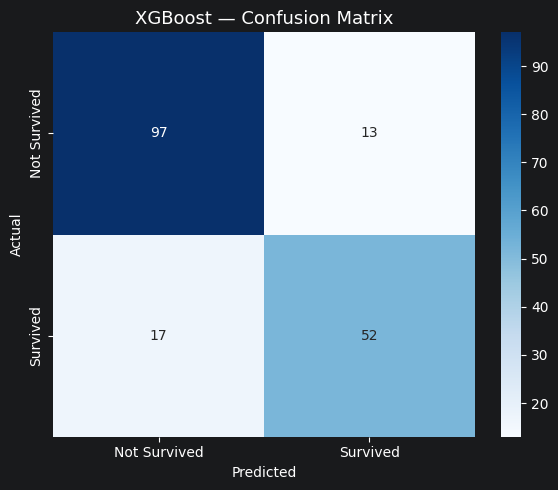

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
plt.title('XGBoost — Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Feature Importance

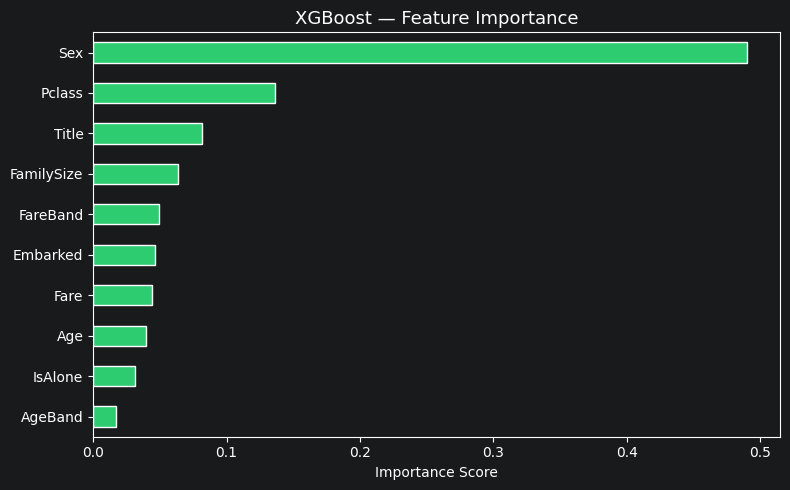

Top feature: Sex


In [22]:
importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('XGBoost — Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Top feature:', importances.idxmax())

### CV Accuracy per Fold

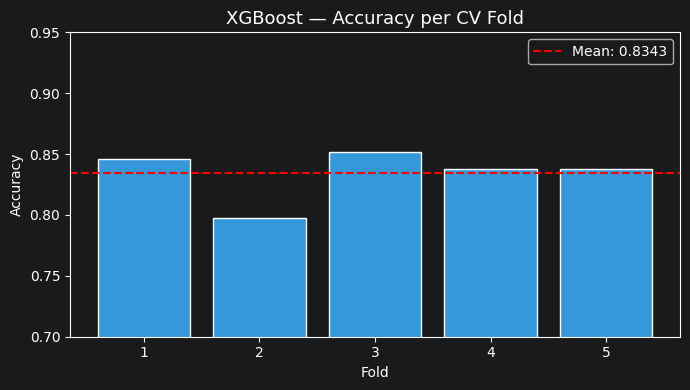

CV Accuracy: 0.8343 +/- 0.0193


In [23]:
final_scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=cv, scoring='accuracy')
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), final_scores, color='#3498db', edgecolor='white')
plt.axhline(final_scores.mean(), color='red', linestyle='--',
            label=f'Mean: {final_scores.mean():.4f}')
plt.title('XGBoost — Accuracy per CV Fold', fontsize=13)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.95)
plt.legend()
plt.tight_layout()
plt.show()
print(f'CV Accuracy: {final_scores.mean():.4f} +/- {final_scores.std():.4f}')

### Save Model — joblib

In [24]:
artifacts = {
    'model':            best_xgb,
    'scaler':           scaler,
    'sex_encoder':      sex_encoder,
    'title_encoder':    title_encoder,
    'embarked_encoder': embarked_encoder,
    'features':         features,
    'best_params':      grid_search.best_params_,
}

joblib.dump(artifacts, 'titanic_model.pkl')
print('Model artifacts saved successfully!')
print('Saved keys:', list(artifacts.keys()))

Model artifacts saved successfully!
Saved keys: ['model', 'scaler', 'sex_encoder', 'title_encoder', 'embarked_encoder', 'features', 'best_params']


### Load & Verify Saved Model

In [25]:
loaded = joblib.load('titanic_model.pkl')
y_pred_loaded = loaded['model'].predict(X_test_scaled)
print(f'Accuracy after reload: {accuracy_score(y_test, y_pred_loaded):.4f}  ✅')
print('Loaded artifacts:', list(loaded.keys()))

Accuracy after reload: 0.8324  ✅
Loaded artifacts: ['model', 'scaler', 'sex_encoder', 'title_encoder', 'embarked_encoder', 'features', 'best_params']
